In [1]:
import pandas as pd

df = pd.read_parquet("/kaggle/input/nvarc-artifacts-puzzles/mixtures/data-00000.parquet")

In [2]:
sample = df.iloc[25]
sample

mix_name                                                        mix1
summary_name1                                               summary1
summary_name2                                               summary1
puzzle_name1                                                0a1d4ef5
puzzle_name2                                                44f52bb0
model_name                                  claude-sonnet-4-20250514
reasoning_level                                                   no
prompt             You are an advanced AI system specialized in c...
reasoning                                                           
completion         <puzzle_analysis>\n\nLet me analyze the key el...
Name: 25, dtype: object

In [3]:
import re

description = sample["completion"]

match = re.search(r"<new_puzzle>(.*?)</new_puzzle>", description, flags=re.DOTALL)
new_puzzle = match.group(1).strip()

print(new_puzzle)

<rules_summary>
The transformation identifies rectangular regions within a large noisy grid, analyzes the color composition within each rectangle, and maps them to a compact output grid. Each rectangle contains a mix of yellow and gray pixels. For each rectangle, if yellow pixels outnumber gray pixels, it maps to green in the output; if gray pixels outnumber yellow pixels, it maps to red in the output; if counts are equal, it maps to blue in the output. The spatial arrangement of rectangles is preserved in the condensed output grid.
</rules_summary>

<input_generation>
1. Create a large grid (typically 20x20 to 25x25) filled with noise colors (black, magenta, orange, brown)
2. Place 4-9 rectangular regions of various sizes (3x2 to 5x4) at different positions
3. Fill each rectangle with a mix of yellow (4) and gray (5) pixels in different proportions
4. Ensure rectangles don't overlap and are clearly distinguishable from the noise background
5. Arrange rectangles in a clear spatial patt

In [4]:
import json

first_name = sample["puzzle_name1"]
second_name = sample["puzzle_name2"]

puzzle_path = f"/kaggle/input/nvarc-synthetic-puzzles/nvarc_training/{first_name}/{first_name}_{second_name}.json"

with open(puzzle_path, "r") as f:
    puzzle_data = json.load(f)
len(puzzle_data)

30

In [5]:
from matplotlib import colors
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator


cmap = colors.ListedColormap([
    "#000000",
    "#0074D9",
    "#FF4136",
    "#2ECC40",
    "#FFDC00",
    "#AAAAAA",
    "#F012BE",
    "#FF851B",
    "#7FDBFF",
    "#870C25",
])

norm = colors.Normalize(vmin=0, vmax=9)


def plot_array(array, title="example"):
    plt.imshow(array, cmap=cmap, norm=norm)
    ax = plt.gca()
    yticks = list(range(array.shape[0]))
    xticks = list(range(array.shape[1]))
    ax.yaxis.set_major_locator(FixedLocator([y - 0.5 for y in yticks]))
    ax.xaxis.set_major_locator(FixedLocator([x - 0.5 for x in xticks]))
    ax.set_yticklabels(yticks)
    ax.set_xticklabels(xticks)
    ax.set_ylabel("Y")
    ax.set_xlabel("X")
    plt.grid(color="white")
    plt.title(title)
    plt.show()
    plt.close()

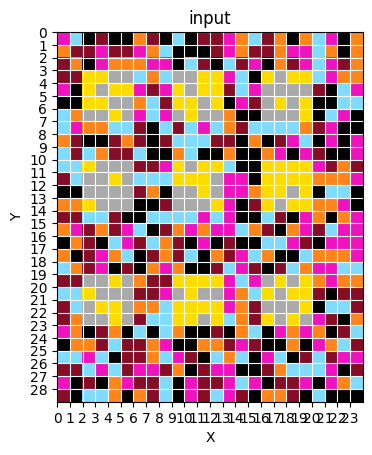

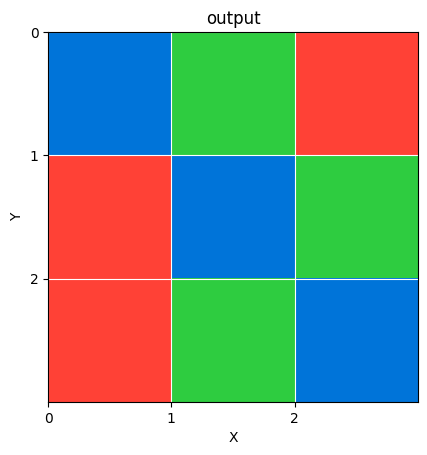

In [6]:
import numpy as np


input_grid = np.array(puzzle_data[0]["input"], dtype=np.uint8)
output_grid = np.array(puzzle_data[0]["output"], dtype=np.uint8)
plot_array(input_grid, "input")
plot_array(output_grid, "output")